[![Text: CC BY-SA 4.0](https://img.shields.io/badge/text-CC%20BY--SA%204.0-lightgrey.svg)](https://creativecommons.org/licenses/by-sa/4.0/)
[![Code: MIT](https://img.shields.io/badge/code-MIT-yellow.svg)](https://opensource.org/license/mit)

This notebook is part of course materials for CS 545: Machine Learning at
Colorado State University. These notebooks are based on the PyTorch version of
[Dive into Deep Learning](https://d2l.ai) by Aston Zhang, Zachary C. Lipton,
Mu Li and Alexander J. Smola, used under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/) and heavily
modified by [Asa Ben-Hur](https://www.cs.colostate.edu/~asa/) with
[Claude](https://claude.com) AI. The text is released under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/); the code is
released under the [MIT license](https://opensource.org/license/mit).

# Implementing Multilayer Perceptrons

Multilayer perceptrons (MLPs) are not much more complex to implement than simple linear models, especially when using full PyTorch functionality.


In [1]:
import torch
from torch import nn
import numpy as np
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [2]:
# if you have a GPU we should enable it
# mps is the pytorch device that supports GPU computations on MacOS

device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using mps device


## Implementation from Scratch

### Setting up the model

Recall that Fashion-MNIST contains 10 classes,
and that each image consists of a $28 \times 28 = 784$
grid of grayscale pixel values.
As before we will disregard the spatial structure
among the pixels for now,
so we can think of this as a classification dataset
with 784 input features and 10 classes.
To begin, we will **implement an MLP
with one hidden layer and 256 hidden units.**
Both the number of layers and their width are adjustable
(they are considered hyperparameters).
Typically, we choose the layer widths to be divisible by larger powers of 2.
This is computationally efficient due to the way
memory is allocated and addressed in hardware.

Again, we will represent our parameters with several tensors.
Note that for every layer, we must keep track of
one weight matrix and one bias vector.

In the code below we use `nn.Parameter`
to automatically register
a class attribute as a parameter to be tracked by `autograd`.


In [3]:
class MLPScratch(nn.Module):
    def __init__(self, num_inputs, num_outputs, num_hiddens, sigma=0.01):
        super().__init__()
        self.W1 = nn.Parameter(torch.randn(num_inputs, num_hiddens) * sigma)
        self.b1 = nn.Parameter(torch.zeros(num_hiddens))
        self.W2 = nn.Parameter(torch.randn(num_hiddens, num_outputs) * sigma)
        self.b2 = nn.Parameter(torch.zeros(num_outputs))
    def forward(self, X):
        X = torch.flatten(X, start_dim=1)
        H = relu(torch.matmul(X, self.W1) + self.b1)
        return torch.matmul(H, self.W2) + self.b2

We will apply this MLP to image data.  Since we are ignoring the structure of our images, we flatten each two-dimensional image into a vector of the appropriate length (using `torch.flatten` / `nn.Flatten`).
Finally, we implement our model with just a few lines of code. Since we use PyTorch's built-in autograd functionality, this is all that it takes.

### The ReLU function

To make sure we know how everything works, we will implement the ReLU activation function ourselves rather than invoking the built-in `relu` function directly.


In [4]:
# the implementation from d2l.ai:
def relu1(X):
    a = torch.zeros_like(X)
    return torch.max(X, a)

# the following is incorrect:
def relu2(X):
    return torch.max(X, 0)

# a better implementation:
def relu3(X):
    # note: torch.tensor(0) is created on the CPU, so if X lived on a GPU
    # (cuda/mps) this would raise a device-mismatch error. clamp (below) avoids this.
    return torch.maximum(X, torch.tensor(0))

# best - doesn't create any extra tensors and is device-safe:
def relu(X):
    return torch.clamp(X, min=0)

In [5]:
A = torch.randn( (5,2) )
A

tensor([[ 6.0688e-01,  1.0047e+00],
        [-1.7952e+00, -3.8809e-01],
        [ 8.7048e-01, -2.9753e-01],
        [ 1.1982e-03, -1.0370e+00],
        [ 1.3432e+00, -8.4147e-01]])

In [6]:
relu2(A)

torch.return_types.max(
values=tensor([1.3432, 1.0047]),
indices=tensor([4, 0]))

Note that `relu2` returned the **per-column maxima** of `A` (a length-2 tensor of
values, together with their row indices), not an elementwise ReLU. This is because
`torch.max(X, 0)` performs a *reduction* along dimension 0 and returns a
`(values, indices)` named tuple — which is why it is the wrong tool for an activation.

In [7]:
relu(A)

tensor([[6.0688e-01, 1.0047e+00],
        [0.0000e+00, 0.0000e+00],
        [8.7048e-01, 0.0000e+00],
        [1.1982e-03, 0.0000e+00],
        [1.3432e+00, 0.0000e+00]])

### Training

The training loop for MLPs is exactly the same as for softmax regression.

In [8]:
def load_fashion_mnist(batch_size, resize=None):
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)
    
    train_dataset = datasets.FashionMNIST(
        root='../data',
        train=True,
        download=True,
        transform=trans
    )
    test_dataset = datasets.FashionMNIST(
        root='../data',
        train=False,
        download=True,
        transform=trans
    )
    
    return (
        DataLoader(train_dataset, batch_size=batch_size, shuffle=True),
        DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    )

In [9]:
def train_epoch(model, train_loader, loss_fn, optimizer):
    model.train()
    total_loss = 0.0   # sum of per-example losses
    total_examples = 0
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * y.numel()
        total_examples += y.numel()
    return total_loss / total_examples


def correctly_classified(y_hat, y):
    """Return the number of correct predictions in a batch."""
    if len(y_hat.shape) > 1:
        y_hat = y_hat.argmax(dim=1)
    return (y_hat == y).type(torch.float32).sum().item()


def evaluate(model, loss_fn, data_loader):
    model.eval()
    total_loss = 0.0
    correct = 0.0
    total = 0
    with torch.no_grad():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)
            y_pred = model(X)
            total_loss += loss_fn(y_pred, y).item() * y.numel()
            correct += correctly_classified(y_pred, y)
            total += y.numel()
    return correct / total, total_loss / total

In [10]:
train_loader, valid_loader = load_fashion_mnist(batch_size=256)
model = MLPScratch(num_inputs=784, num_outputs=10, num_hiddens=256)
model = model.to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
loss_fn = nn.CrossEntropyLoss()

In [11]:
epochs = 10
# overall loss / accuracy value for each epoch:
train_losses, valid_losses, valid_accs = [], [] , []

for epoch in range(epochs) :
    print("epoch", epoch + 1)
    train_loss = train_epoch(model, train_loader, loss_fn, optimizer)
    valid_acc, valid_loss = evaluate(model, loss_fn, valid_loader)
    train_losses.append(train_loss)
    valid_losses.append(valid_loss)
    valid_accs.append(valid_acc)
    print ("loss", train_loss, "accuracy: ", valid_acc)

epoch 1
loss 1.0468750692049662 accuracy:  0.7408
epoch 2
loss 0.5994653964519501 accuracy:  0.795
epoch 3
loss 0.5163998653411865 accuracy:  0.8039
epoch 4
loss 0.4838269076824188 accuracy:  0.8296
epoch 5
loss 0.4559736727078756 accuracy:  0.8132
epoch 6
loss 0.4359447691599528 accuracy:  0.8368
epoch 7
loss 0.4197920248508453 accuracy:  0.8396
epoch 8
loss 0.40734460945129397 accuracy:  0.8464
epoch 9
loss 0.3932806399504344 accuracy:  0.8423
epoch 10
loss 0.38273991815249125 accuracy:  0.8358


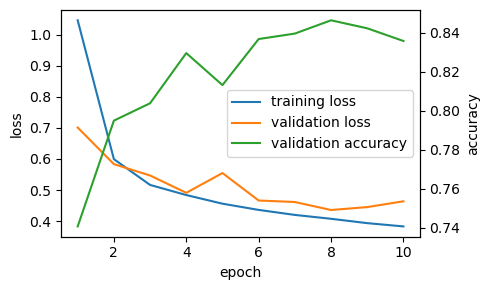

In [12]:
from matplotlib import pyplot as plt

epochs_axis = range(1, len(train_losses) + 1)
fig, ax_loss = plt.subplots(figsize=(5, 3))

# left y-axis: losses
l1 = ax_loss.plot(epochs_axis, train_losses, label='training loss')
l2 = ax_loss.plot(epochs_axis, valid_losses, label='validation loss')
ax_loss.set_xlabel('epoch')
ax_loss.set_ylabel('loss')

# right y-axis: accuracy (different scale, so give it its own axis)
ax_acc = ax_loss.twinx()
l3 = ax_acc.plot(epochs_axis, valid_accs, label='validation accuracy',
                 color='tab:green')
ax_acc.set_ylabel('accuracy')

# combine the legends from both axes into one
lines = l1 + l2 + l3
ax_loss.legend(lines, [ln.get_label() for ln in lines], loc='center right')
plt.tight_layout();

## Concise Implementation

As you might expect, by relying on the neural network functionality of PyTorch, we can implement MLPs even more concisely.

### Model

Here is our model implemented using the PyTorch `Sequential` construct.

In [13]:
class MLP(nn.Module):
    def __init__(self, num_outputs, num_hiddens):
        super().__init__()
        self.net = nn.Sequential(nn.Flatten(), nn.LazyLinear(num_hiddens),
                                 nn.ReLU(), nn.LazyLinear(num_outputs))
    def forward(self, X) :
        return self.net(X)

### Training

The training loop is exactly the same
as when we implemented softmax regression.
This modularity enables us to separate
matters concerning the model architecture
from orthogonal considerations.


In [14]:
train_loader, valid_loader = load_fashion_mnist(batch_size=256)
model = MLP(num_outputs=10, num_hiddens=256)
model = model.to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
#optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)  # if trying Adam, use a much smaller lr than SGD
loss_fn = nn.CrossEntropyLoss()

In [15]:
epochs = 10
# overall loss / accuracy value for each epoch:
train_losses, valid_losses, valid_accs = [], [] , []

for epoch in range(epochs) :
    print("epoch", epoch + 1)
    train_loss = train_epoch(model, train_loader, loss_fn, optimizer)
    valid_acc, valid_loss = evaluate(model, loss_fn, valid_loader)
    train_losses.append(train_loss)
    valid_losses.append(valid_loss)
    valid_accs.append(valid_acc)
    print ("loss", train_loss, "accuracy: ", valid_acc)

epoch 1
loss 0.8607319127082824 accuracy:  0.7375
epoch 2
loss 0.5534530255317688 accuracy:  0.8086
epoch 3
loss 0.4970204823811849 accuracy:  0.8103
epoch 4
loss 0.4629535421530406 accuracy:  0.8028
epoch 5
loss 0.4385984667460124 accuracy:  0.8393
epoch 6
loss 0.42012357292175295 accuracy:  0.7857
epoch 7
loss 0.4038036412715912 accuracy:  0.838
epoch 8
loss 0.39259469572703043 accuracy:  0.8416
epoch 9
loss 0.3818930089314779 accuracy:  0.8423
epoch 10
loss 0.3721321893533071 accuracy:  0.8556


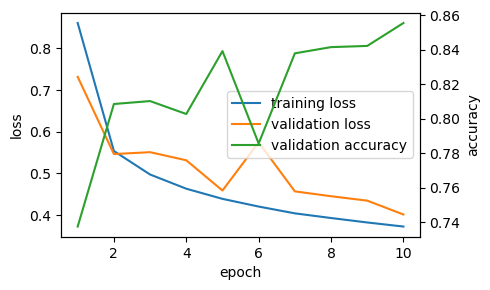

In [16]:
from matplotlib import pyplot as plt

epochs_axis = range(1, len(train_losses) + 1)
fig, ax_loss = plt.subplots(figsize=(5, 3))

# left y-axis: losses
l1 = ax_loss.plot(epochs_axis, train_losses, label='training loss')
l2 = ax_loss.plot(epochs_axis, valid_losses, label='validation loss')
ax_loss.set_xlabel('epoch')
ax_loss.set_ylabel('loss')

# right y-axis: accuracy (different scale, so give it its own axis)
ax_acc = ax_loss.twinx()
l3 = ax_acc.plot(epochs_axis, valid_accs, label='validation accuracy',
                 color='tab:green')
ax_acc.set_ylabel('accuracy')

# combine the legends from both axes into one
lines = l1 + l2 + l3
ax_loss.legend(lines, [ln.get_label() for ln in lines], loc='center right')
plt.tight_layout();

## Summary

Now that we have more practice in designing deep networks, the step from a single to multiple layers of deep networks does not pose such a significant challenge any longer. In particular, we can reuse the training algorithm and data loader. Note, though, that implementing MLPs from scratch is nonetheless messy: naming and keeping track of the model parameters makes it difficult to extend models. For instance, imagine wanting to insert another layer between layers 42 and 43...

Nonetheless, you have now reached the state of the art of the late 1980s when fully connected deep networks were the method of choice for neural network modeling. Our next conceptual step will be to consider images.


## Exercises

1. Change the number of hidden units `num_hiddens` and plot how its number affects the accuracy of the model. What is the best value of this hyperparameter?
1. Try adding a hidden layer to see how it affects the results.
1. How does changing the learning rate alter your results? With all other parameters fixed, which learning rate gives you the best results? How does this relate to the number of epochs?
1. Try different activation functions. Which one works best?